In [33]:
from PA_OmniNet.helper_functions import *
from PA_OmniNet.testing_model import LightningModel
from PA_OmniNet.helper_functions import *
import matplotlib.pyplot as plt
from PA_OmniNet.testing_functions import *
from torchmetrics.image import StructuralSimilarityIndexMeasure
ssim = StructuralSimilarityIndexMeasure()

In [34]:
mice = ['../Datasets/optoacousticsparse/mice_sparse16_recon_256.mat', '../Datasets/optoacousticsparse/mice_sparse32_recon_256.mat', '../Datasets/optoacousticsparse/mice_sparse128_recon_256.mat']
v_phantom = ['../Datasets/optoacousticsparse/v_phantom_sparse16_recon_256.mat', '../Datasets/optoacousticsparse/v_phantom_sparse32_recon_256.mat', '../Datasets/optoacousticsparse/v_phantom_full_recon_256.mat']
phantom = ['../Datasets/optoacousticsparse/phantom_sparse16_recon_256.mat', '../Datasets/optoacousticsparse/phantom_sparse32_recon_256.mat', '../Datasets/optoacousticsparse/phantom_full_recon_256.mat']


model_pth_mouse='final_model_weight/Neuralizer/final_model_semifinalpatient_early.pth'
hparams = {
    "batch_size": 32,
    "learning_rate": 1e-4,
    "nb_levels": 4,
    "nb_inner_channels": 32,
    "nb_conv_layers_per_stage": 2,
    "data_slice_only": True,
    "max_epochs": 250,
}
model = LightningModel(hparams)
state_dict = torch.load(model_pth_mouse, map_location=torch.device('cpu'))
model.load_state_dict(state_dict)

C:\Users\olivi\AppData\Local\Temp\ipykernel_209796\3224886580.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_pth_mouse, map_location=torc

<All keys matched successfully>

In [35]:
def preprocess_mat(image, size=(256, 256)):
    image = (image - image.min()) / (image.max() - image.min())
    image = cv2.resize(image, size, interpolation=cv2.INTER_LINEAR)
    image = np.stack([image] * 3, axis=-1)
    image = torch.tensor(image)
    image = image.unsqueeze(0)
    image = image.permute(0, 3, 1, 2).float()
    return image


def preprocess_context_mat(context_in, context_out):
    context_in_preprocessed = np.array([preprocess_mat(c) for c in context_in])
    context_in_preprocessed = (
        torch.tensor(context_in_preprocessed).permute(1, 0, 2, 3, 4))
    context_out_preprocessed = np.array(
        [preprocess_mat(c) for c in context_out])
    context_out_preprocessed = (
        torch.tensor(context_out_preprocessed).permute(1, 0, 2, 3, 4))
    return context_in_preprocessed, context_out_preprocessed


def preprocess_context(context_in, context_out):
    context_in_preprocessed = np.array([preprocess(c) for c in context_in])
    context_in_preprocessed = (
        torch.tensor(context_in_preprocessed).permute(1, 0, 2, 3, 4))
    context_out_preprocessed = np.array([preprocess(c) for c in context_out])
    context_out_preprocessed = (
        torch.tensor(context_out_preprocessed).permute(1, 0, 2, 3, 4))
    return context_in_preprocessed, context_out_preprocessed




def data_loader_formatter_mat(in_filepath, out_filepath):
    with h5py.File(in_filepath, 'r') as infile:
        first_key = list(infile.keys())[0]
        data_in = infile[first_key][()]

    with h5py.File(out_filepath, 'r') as outfile:
        first_key = list(outfile.keys())[0]
        data_out = outfile[first_key][()]

    return data_in, data_out

def preprocess_batch(images, size=(256, 256)):

    processed_images = []
    for image in images:
        processed_image = preprocess_mat(image, size)
        processed_images.append(processed_image)

    return torch.cat(processed_images, dim=0)


In [42]:
CONTEXT_SIZE = 16


X, y = data_loader_formatter_mat(mice[0], mice[2])
size = X.shape[0]
indices = np.arange(size)
train_end = int(0.7 * size)
val_end = train_end + int(0.2 * size)

train_indices = indices[:train_end]
val_indices = indices[train_end:val_end]
test_indices = indices[val_end:]

X_train, y_train = X[train_indices], y[train_indices]
X_val, y_val = X[val_indices], y[val_indices]
X_test, y_test = X[test_indices], y[test_indices]



X_train = preprocess_batch(X_train)
y_train = preprocess_batch(y_train)

X_context = X_train[:CONTEXT_SIZE]
y_context = y_train[:CONTEXT_SIZE]

X_val = preprocess_batch(X_val)
y_val = preprocess_batch(y_val)

X_test = preprocess_batch(X_test)
y_test = preprocess_batch(y_test)

print("Train set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)
print("Context samples:", X_context.shape, y_context.shape)

Train set: torch.Size([191, 3, 256, 256]) torch.Size([191, 3, 256, 256])
Validation set: torch.Size([54, 3, 256, 256]) torch.Size([54, 3, 256, 256])
Test set: torch.Size([29, 3, 256, 256]) torch.Size([29, 3, 256, 256])
Context samples: torch.Size([16, 3, 256, 256]) torch.Size([16, 3, 256, 256])


In [43]:
print(f'Total length: {X.shape[0]}\nTrain Length: {X_train.shape[0]}\nValidation Length: {X_val.shape[0]}\nTest Length: {X_test.shape[0]}\nContext size: {X_context.shape[0]}')

Total length: 274
Train Length: 191
Validation Length: 54
Test Length: 29
Context size: 16


In [44]:
i = 0
input = X_test[i]
ground_truth = y_test[i]
output = model.forward(input.unsqueeze(0), X_context.unsqueeze(0), y_context.unsqueeze(0))

input_show = input.detach().squeeze(0).select(0, 0).numpy()
input_show = (input_show - input_show.min()) / (input_show.max() - input_show.min())

normalized_output = (output - output.min()) / (output.max() - output.min())
output_image = normalized_output.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()

y_show = ground_truth.detach().squeeze(0).select(0, 0).numpy()
y_show = (y_show - y_show.min()) / (y_show.max() - y_show.min())

In [45]:
print(input_show.shape, output.shape, ground_truth.shape)

(256, 256) torch.Size([1, 3, 256, 256]) torch.Size([3, 256, 256])


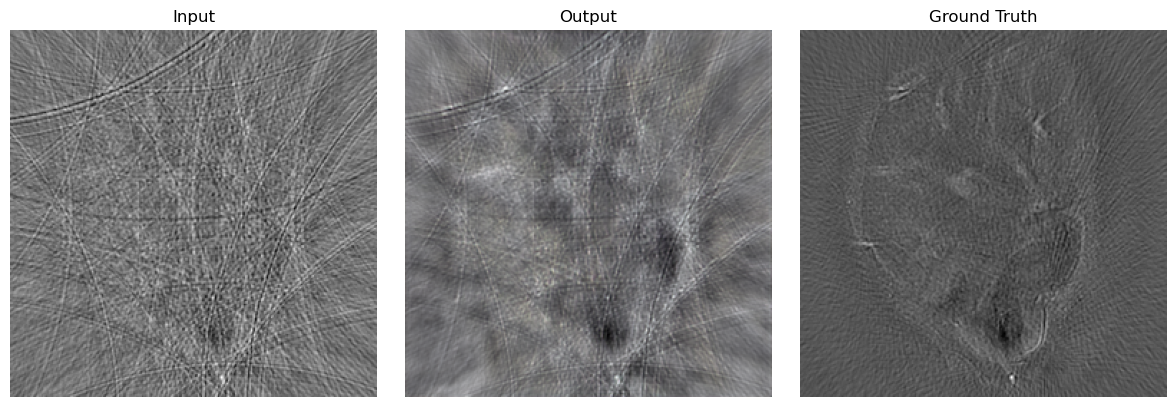

RMSE: 0.1321
PSNR: 17.5791
SSIM: 0.5356


In [46]:
plt.figure(figsize=(12, 4))  

plt.subplot(1, 3, 1)
plt.imshow(input_show, cmap="gray")
plt.title("Input")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(output_image, cmap="gray")
plt.title("Output")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(y_show, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.tight_layout() 
plt.show()

print(f"RMSE: {compute_rmse(ground_truth, output.squeeze(0)):.4f}\n"
      f"PSNR: {compute_psnr(ground_truth, output.squeeze(0)):.4f}\n"
      f"SSIM: {ssim(ground_truth.unsqueeze(0), output).item():.4f}")

In [41]:
csv_file_name = "Neuralizer_phantom_32.csv"  
import csv
# with open(csv_file_name, mode="w", newline="") as file:
#     writer = csv.writer(file)
#     writer.writerow(["Index", "SSIM", "RMSE", "PSNR"])  # Write the headers
from torchmetrics.image import StructuralSimilarityIndexMeasure
ssim = StructuralSimilarityIndexMeasure(data_range=1.0)
for i in range(len(X_test) - 1):
    input = X_test[i]
    ground_truth = y_test[i]
    output = model.forward(input.unsqueeze(0), X_context.unsqueeze(0), y_context.unsqueeze(0))
    
    input_show = input.detach().squeeze(0).select(0, 0).numpy()
    input_show = (input_show - input_show.min()) / (input_show.max() - input_show.min())
    
    normalized_output = (output - output.min()) / (output.max() - output.min())
    output_image = normalized_output.squeeze(0).permute(1, 2, 0).detach().cpu().numpy()
    
    y_show = ground_truth.detach().squeeze(0).select(0, 0).numpy()
    y_show = (y_show - y_show.min()) / (y_show.max() - y_show.min())
    rmse_val = compute_rmse(ground_truth, output.squeeze(0))
    psnr_val = compute_psnr(ground_truth, output.squeeze(0))
    ssim_val = ssim(ground_truth.unsqueeze(0), output).item()
    print(i, ssim_val, rmse_val, psnr_val)
    with open(csv_file_name, mode="a", newline="") as file:
        writer = csv.writer(file)
        writer.writerow([i, ssim_val, rmse_val, psnr_val])

print(f"Metrics saved to {csv_file_name}")

0 0.7496187090873718 0.12119338720210401 18.330421297899523


KeyboardInterrupt: 